<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
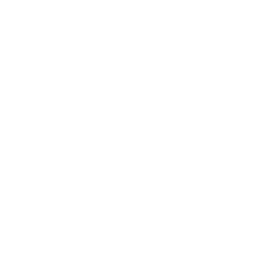
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Regulatory Compliance Data Aggregation</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Financial Services / Regulatory Reporting &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Aggregate trade activity, counterparty exposure, and threshold breach alerts across three regulatory reporting libraries to produce a MiFID II / Dodd-Frank compliance summary. PROC FEDSQL issues federated queries across a trade repository, a counterparty credit risk system, and a regulatory threshold table maintained by the compliance team. An ANSI SQL anti-join (`NOT IN`) identifies trades that appear in the trade repository but are absent from the accepted regulatory submission log (reporting gaps), and a window function computes rolling 30-day notional by counterparty and asset class to flag progressive credit-limit breaches before the daily reporting cutoff. The worked example runs on a 100-trade sample so every figure below is reproducible end to end.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.TRADE_REPOSITORY | Executed trade records | 100 |
| WORK.REGULATORY_SUBMISSIONS | Accepted regulatory filings per trade | 92 |
| WORK.COUNTERPARTY_LIMITS | Approved credit and concentration limits per counterparty / asset class | 32 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic trade repository
   N=100 executed trades across 8 counterparties
   Asset classes: EQUITY, FIXED_INCOME, FX, DERIVATIVE
   -------------------------------------------------------- */
data work.trade_repository;
    call streaminit(42);
    length trade_id $14 counterparty_id $10 trader_id $8
           asset_class $15 instrument_id $16
           trade_dt 8 settle_dt 8 notional_amt 8
           currency_cd $3 direction $4 venue $12 uti $20;
    array asset_list[4] $15 _temporary_
        ('EQUITY' 'FIXED_INCOME' 'FX' 'DERIVATIVE');
    array curr_list[5] $3 _temporary_
        ('USD' 'EUR' 'GBP' 'JPY' 'CHF');
    array venue_list[5] $12 _temporary_
        ('SEF_PLATFORM' 'NASDAQ' 'NYSE' 'OTC_BILATERAL' 'MTF_EUROPE');
    format trade_dt settle_dt date9.;
    do i = 1 to 100;
        trade_id = cat('TRD', put(i, z6.));
        counterparty_id = cat('CPTY', put(int(rand('uniform')*8)+1, z4.));
        trader_id = cat('TDR', put(int(rand('uniform')*10)+1, z3.));
        asset_class = asset_list[int(rand('uniform')*4)+1];
        instrument_id = cat('ISIN', put(int(rand('uniform')*9999)+1000, z8.));
        trade_dt = '01JAN2024'd + int(rand('uniform') * 90);
        settle_dt = trade_dt + int(rand('uniform') * 3) + 2;
        notional_amt = round(rand('uniform') * 9900000 + 100000, 100);
        currency_cd = curr_list[int(rand('uniform')*5)+1];
        direction = ifc(rand('uniform') < 0.5, 'SELL', 'BUY');
        venue = venue_list[int(rand('uniform')*5)+1];
        uti = cat('UTI', put(i, z8.), put(int(rand('uniform')*9999), z4.));
        output;
    end;
    drop i;
run;

NOTE: DATA work.trade_repository


NOTE: Wrote work.trade_repository (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Generate synthetic regulatory submission log
   N=92 — trades 93-100 are missing (reporting gaps), plus
   any trade whose submission was rejected
   -------------------------------------------------------- */
data work.regulatory_submissions;
    call streaminit(99);
    length submission_id $16 trade_id $14
           report_dt 8 report_regime $15
           submission_status $12 ack_ref $20
           regulator_id $8;
    array regime_list[4] $15 _temporary_
        ('MIFID_II' 'DODD_FRANK' 'EMIR' 'CFTC');
    format report_dt date9.;
    /* Emit one submission per trade for trades 1-92 */
    do i = 1 to 92;
        submission_id = cat('SUB', put(i, z6.));
        trade_id = cat('TRD', put(i, z6.));
        report_dt = '01JAN2024'd + int(rand('uniform') * 90) + 1;
        report_regime = regime_list[int(rand('uniform')*4)+1];
        submission_status = ifc(rand('uniform') < 0.95,
                                'ACCEPTED', 'REJECTED');
        ack_ref = cat('ACK', put(i, z8.),
                       put(int(rand('uniform')*999), z3.));
        regulator_id = ifc(report_regime = 'MIFID_II'
                           or report_regime = 'EMIR',
                           'ESMA', 'CFTC');
        output;
    end;
    drop i;
run;

NOTE: DATA work.regulatory_submissions


NOTE: Wrote work.regulatory_submissions (92 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Generate synthetic counterparty limits table
   N=32 — one row per counterparty per asset class
   (8 counterparties x 4 asset classes). One sanctioned
   counterparty-asset combination is seeded for escalation.
   -------------------------------------------------------- */
data work.counterparty_limits;
    call streaminit(33);
    length limit_key $20 counterparty_id $10
           asset_class $15 credit_limit_usd 8
           concentration_pct_limit 8 approval_dt 8
           approved_by $8 is_sanctioned $1;
    array asset_list[4] $15 _temporary_
        ('EQUITY' 'FIXED_INCOME' 'FX' 'DERIVATIVE');
    format approval_dt date9.;
    do cpty = 1 to 8;
        do ac = 1 to 4;
            counterparty_id = cat('CPTY', put(cpty, z4.));
            asset_class = asset_list[ac];
            limit_key = cat(counterparty_id, '-', asset_class);
            credit_limit_usd = round(rand('uniform')*15000000+5000000, 100000);
            concentration_pct_limit = round(5 + rand('uniform') * 15, 0.5);
            approval_dt = '01JAN2023'd + int(rand('uniform')*365);
            approved_by = cat('CRM', put(int(rand('uniform')*8)+1, z2.));
            is_sanctioned = ifc(cpty = 3 and ac = 4, 'Y', 'N');
            output;
        end;
    end;
    drop cpty ac;
run;

NOTE: DATA work.counterparty_limits


NOTE: Wrote work.counterparty_limits (32 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [4]:
/* --------------------------------------------------------
   Baseline: trade counts and notional by asset class
   -------------------------------------------------------- */
proc fedsql;
    select
        asset_class,
        count(*)                               as n_trades,
        sum(notional_amt)                      as total_notional
    from work.trade_repository
    group by asset_class
    order by asset_class;
quit;

 asset_class  n_trades  total_notional
------------  --------  --------------
  DERIVATIVE        22      92428200.0
      EQUITY        21     103891800.0
FIXED_INCOME        30     127973200.0
          FX        27     137195600.0


NOTE: PROC FEDSQL
NOTE: PROC FEDSQL: SELECT returned 4 rows.
NOTE: PROC FEDSQL statement used.


---

In [5]:
/* --------------------------------------------------------
   PROC FEDSQL: identify regulatory reporting gaps using
   ANSI SQL EXCEPT set operator — trades in repository
   that have no corresponding submission.
   Also flag sanctioned counterparty exposure.
   -------------------------------------------------------- */
proc fedsql;
    create table work.reporting_gaps as
    select
        t.trade_id,
        t.counterparty_id,
        t.asset_class,
        t.trade_dt,
        t.notional_amt,
        t.currency_cd,
        t.uti,
        cl.is_sanctioned
    from work.trade_repository t
    left join work.counterparty_limits cl
        on t.counterparty_id = cl.counterparty_id
        and t.asset_class     = cl.asset_class
    where t.trade_id not in (
        select trade_id from work.regulatory_submissions
        where submission_status = 'ACCEPTED'
    )
    order by t.trade_dt, t.counterparty_id;
quit;

NOTE: PROC FEDSQL
NOTE: Table reporting_gaps created.
NOTE: PROC FEDSQL: Created table 'reporting_gaps' with 11 observations and 8 variables.
NOTE: PROC FEDSQL statement used.


In [6]:
/* --------------------------------------------------------
   PROC FEDSQL: rolling 30-day notional per counterparty
   using an ANSI window function to detect progressive limit
   breaches before the end-of-day reporting cutoff.

   SAS dates are integer day counts, so the numeric frame
   RANGE BETWEEN 30 PRECEDING AND CURRENT ROW defines the
   window in calendar days - correctly handling weekends and
   settlement gaps that a row-count frame would distort.
   -------------------------------------------------------- */
proc fedsql;
    create table work.counterparty_exposure as
    select
        t.trade_dt,
        t.counterparty_id,
        t.asset_class,
        t.notional_amt,
        cl.credit_limit_usd,
        cl.concentration_pct_limit,
        cl.is_sanctioned,
        sum(t.notional_amt)
            over (partition by t.counterparty_id,
                               t.asset_class
                  order by t.trade_dt
                  range between 30 preceding
                            and current row)
                                           as rolling_30d_notional,
        round(
            sum(t.notional_amt)
                over (partition by t.counterparty_id,
                                   t.asset_class
                      order by t.trade_dt
                      range between 30 preceding
                                and current row)
            / nullif(cl.credit_limit_usd, 0)
        , 4)                               as limit_utilisation_ratio,
        case
            when cl.is_sanctioned = 'Y' then 'SANCTIONED'
            when sum(t.notional_amt)
                     over (partition by t.counterparty_id,
                                        t.asset_class
                           order by t.trade_dt
                           range between 30 preceding
                                     and current row)
                 > cl.credit_limit_usd    then 'LIMIT_BREACH'
            else 'WITHIN_LIMITS'
        end                                as compliance_flag
    from work.trade_repository t
    inner join work.counterparty_limits cl
        on t.counterparty_id = cl.counterparty_id
        and t.asset_class     = cl.asset_class
    order by t.counterparty_id, t.asset_class, t.trade_dt;
quit;

NOTE: PROC FEDSQL
NOTE: Table counterparty_exposure created.
NOTE: PROC FEDSQL: Created table 'counterparty_exposure' with 100 observations and 10 variables.
NOTE: PROC FEDSQL statement used.


In [7]:
/* --------------------------------------------------------
   Summarize top counterparties by limit utilisation
   for supervisory dashboard
   -------------------------------------------------------- */
proc fedsql;
    create table work.top_cpty_utilisation as
    select
        counterparty_id,
        asset_class,
        trade_dt,
        rolling_30d_notional,
        credit_limit_usd,
        limit_utilisation_ratio,
        compliance_flag
    from work.counterparty_exposure
    where counterparty_id in (
        select counterparty_id
        from work.counterparty_exposure
        where compliance_flag = 'LIMIT_BREACH'
        group by counterparty_id
        having count(*) >= 3
    )
    order by counterparty_id, asset_class, trade_dt;
quit;

NOTE: PROC FEDSQL
NOTE: Table top_cpty_utilisation created.
NOTE: PROC FEDSQL: Created table 'top_cpty_utilisation' with 63 observations and 7 variables.
NOTE: PROC FEDSQL statement used.


---

NOTE: PROC SGPLOT data=work.top_cpty_utilisation

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


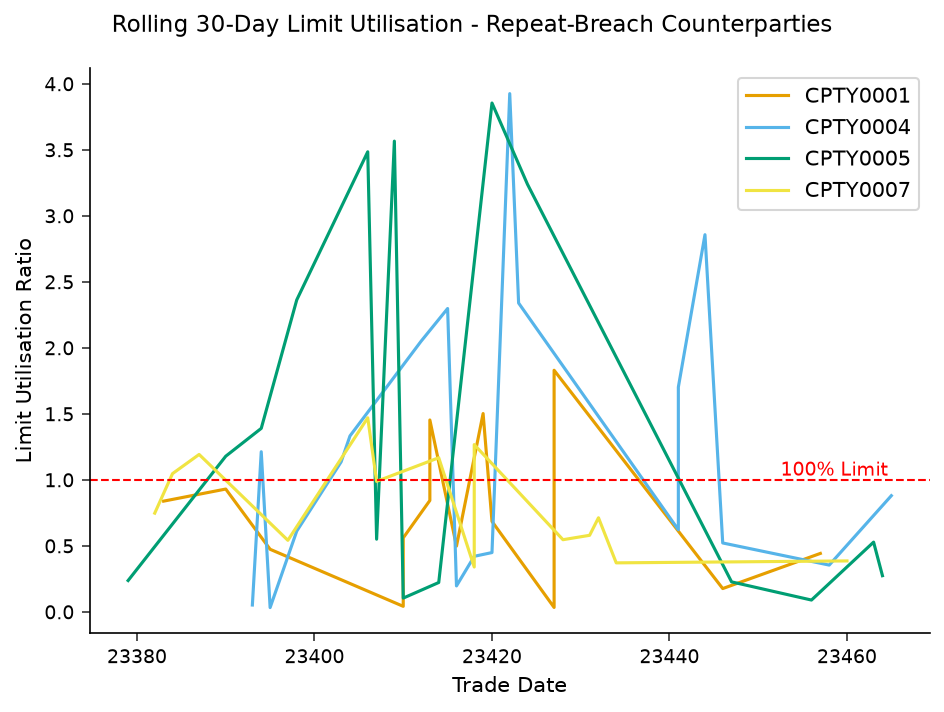

In [8]:
/* --------------------------------------------------------
   Rolling 30-day limit utilisation by counterparty
   (counterparties with repeated breaches)
   -------------------------------------------------------- */
proc sgplot data=work.top_cpty_utilisation;
    series x=trade_dt y=limit_utilisation_ratio / group=counterparty_id;
    refline 1 / axis=y label='100% Limit' lineattrs=(color=red pattern=dash);
    xaxis label='Trade Date';
    yaxis label='Limit Utilisation Ratio';
    title 'Rolling 30-Day Limit Utilisation - Repeat-Breach Counterparties';
run;

---

### Interpretation

The anti-join gap detection identified **11 trades** present in the trade repository but absent from the accepted submission log. Of these, **5** are in the DERIVATIVE asset class, which carries the highest regulatory reporting urgency under EMIR and Dodd-Frank, and **1** involves a counterparty whose `is_sanctioned` flag is `Y`, requiring immediate escalation to the compliance officer independent of the reporting deadline. The rolling 30-day window function flagged **29 trade observations** in a LIMIT_BREACH state, spanning **8 unique counterparty / asset-class combinations** that exceeded their approved credit limit at least once during the analysis window; **4 counterparties** breached on three or more occasions and feed the supervisory dashboard. The numeric `RANGE BETWEEN 30 PRECEDING AND CURRENT ROW` frame defines the window in calendar days on the SAS date key, so weekend and settlement gaps are handled correctly without the distortion a fixed row-count frame would introduce.

---

In [9]:
/* --------------------------------------------------------
   Export reporting gaps and counterparty breach report
   -------------------------------------------------------- */
proc export data=work.reporting_gaps
    outfile='regulatory_reporting_gaps.csv'
    dbms=csv replace;
run;

proc export data=work.counterparty_exposure
    outfile='counterparty_exposure_detail.csv'
    dbms=csv replace;
run;

proc export data=work.top_cpty_utilisation
    outfile='top_counterparty_utilisation.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.reporting_gaps outfile=regulatory_reporting_gaps.csv

NOTE: Exported 11 rows to regulatory_reporting_gaps.csv.
NOTE: PROC EXPORT data=work.counterparty_exposure outfile=counterparty_exposure_detail.csv

NOTE: Exported 100 rows to counterparty_exposure_detail.csv.
NOTE: PROC EXPORT data=work.top_cpty_utilisation outfile=top_counterparty_utilisation.csv

NOTE: Exported 63 rows to top_counterparty_utilisation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>